In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data = pd.read_csv("/content/Weather forecast data.csv")
data.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614189,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


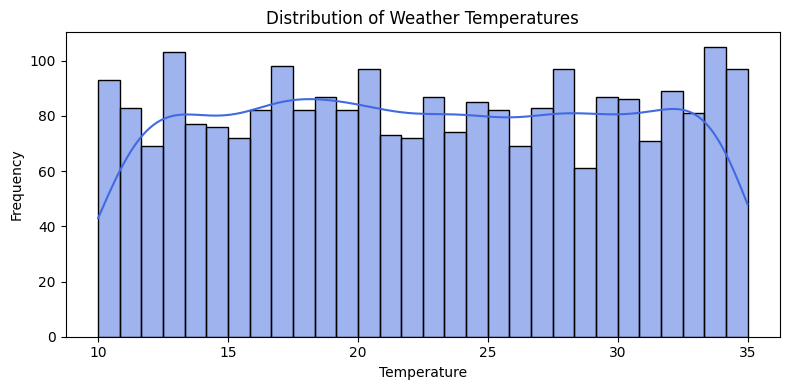

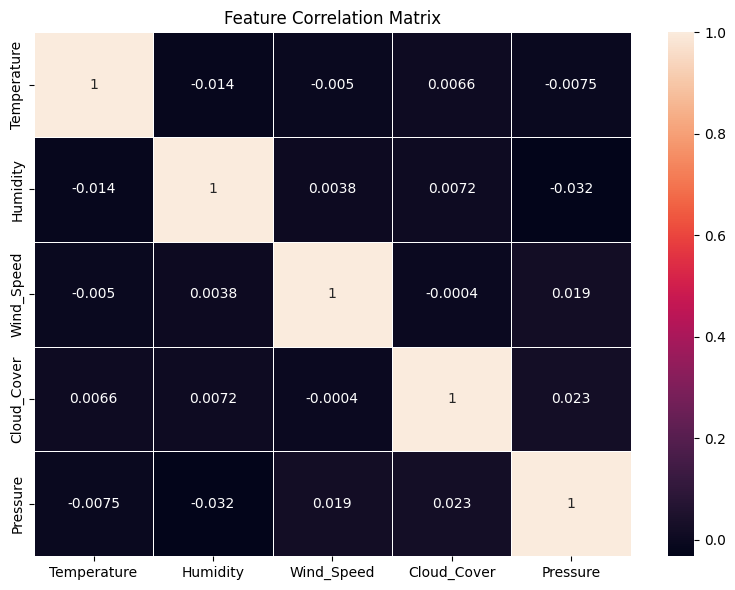

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(data['Temperature'], bins=30, kde=True, color='royalblue')
plt.title('Distribution of Weather Temperatures')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

numerical_data = data.drop(columns=['Rain'])
sns.heatmap(numerical_data.corr(), annot=True,  linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()



--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 52.151327478540196
R-squared Score (R2): -0.006504738553678502


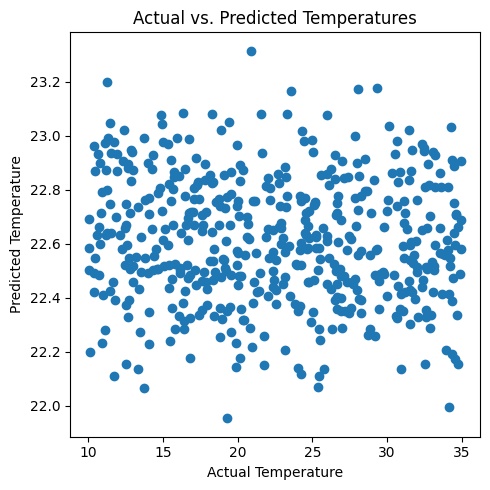

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X = data[['Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure']]
y = data['Temperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared Score (R2): {r2}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred)
plt.title('Actual vs. Predicted Temperatures')

plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.tight_layout()
plt.show()